In [6]:
# ============================================================
# Scripts 4.13–4.16 (Updated): Quantum SOFT Setup
# ============================================================
from qiskit.circuit.library import QFT
import matplotlib.pyplot as plt
import numpy as np

# --- Parameter sistem: DNA adenine-thymine tautomerisasi ---
d     = 6           # 6 qubit → 2^6 = 64 grid points
mass  = 1
xMin  = -5
xMax  = -xMin
x     = np.linspace(xMin, xMax, 2**d)

# Potential Energy Surface: double-well untuk proton hopping A-T
# Analogi: seperti dua lembah (bentuk amino-keto dan imino-enol) dipisah bukit
VV = (0.429*x - 1.126*x**2 - 0.143*x**3 + 0.563*x**4) * 0.1

# Initial state: Gaussian wavepacket terlokalisir di x=1 (lembah kiri)
mu    = 1
alpha = 1
psi   = (alpha/np.pi)**0.25 * np.exp(-alpha * (x - mu)**2 * 0.5)
psi  /= np.sqrt(np.sum(np.abs(psi)**2))  # normalisasi

# --- Propagators ---
N  = 2**d
dx = (xMax - xMin) / (N - 1)
dp = 2 * np.pi / (xMax - xMin)

# Momentum grid (shifted untuk FFT convention)
p = np.array([dp * (i - N/2) for i in range(N)])
p = np.fft.fftshift(p)

time_step = 0.01

# Propagator potensial (diagonal di basis posisi)
# Analogi: setiap titik posisi mendapat "putaran fase" sesuai energi potensialnya
VVd_prop  = np.diag(np.exp(-1j * VV * time_step))

# Propagator kinetik (diagonal di basis momentum)
# Analogi: setiap mode momentum mendapat "putaran fase" sesuai energi kinetiknya
KEd_prop  = np.diag(np.exp(-1j * p**2 / (2*mass) * time_step))

In [7]:
# ============================================================
# Script 4.16–4.17 (Updated): Quantum SOFT Circuit + Execution
# ============================================================
# PERUBAHAN BESAR Qiskit 2.x:
# - execute() DIHAPUS → gunakan StatevectorSimulator.run() atau Statevector class
# - QuantumCircuit.initialize() DEPRECATED → gunakan .prepare_state()

from qiskit.circuit.library import QFT
import qiskit 
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator

nqubits = d
q_reg   = QuantumRegister(nqubits, name='q')
qc      = QuantumCircuit(q_reg)

# Inisialisasi state: encode amplitudo psi ke amplitudo qubit
# Qiskit 2.x: gunakan prepare_state() sebagai pengganti initialize()
# Analogi: "upload" data wavefunction ke dalam komputer kuantum
qc.prepare_state(psi.tolist(), q_reg[:])

# Loop Trotter: 600 langkah waktu, masing-masing dt = 0.01
# Paper menggunakan trange (tqdm) untuk progress bar
n_steps = 600
print(f"Membangun circuit untuk {n_steps} langkah SOFT...")

for k in range(n_steps):
    # Step 1: Potential propagator (diagonal gate di basis posisi)
    bound_op = Operator(VVd_prop)
    qc.append(bound_op, q_reg)

    # Step 2: QFT† (inverse QFT = forward numpy FFT)
    # CATATAN: di Qiskit, QFT(inverse=True) = numpy.fft.fft
    qc.append(QFT(d, do_swaps=True, inverse=True), q_reg)

    # Step 3: Kinetic propagator (diagonal gate di basis momentum)
    bound_op = Operator(KEd_prop)
    qc.append(bound_op, q_reg)

    # Step 4: QFT (forward QFT = numpy.fft.ifft)
    qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)

print(f"Circuit depth: {qc.depth()}")

# Eksekusi: Qiskit 2.x gunakan Statevector (lebih efisien dari Aer untuk ini)
# Analogi: "print foto" state akhir setelah semua operasi
from qiskit.quantum_info import Statevector
psin_sv = Statevector(qc)
psin    = np.array(psin_sv)  # konversi ke numpy array

Membangun circuit untuk 600 langkah SOFT...


/tmp/ipykernel_3538844/2520355252.py:34: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d, do_swaps=True, inverse=True), q_reg)
/tmp/ipykernel_3538844/2520355252.py:41: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(d, do_swaps=True, inverse=False), q_reg)


Circuit depth: 2401


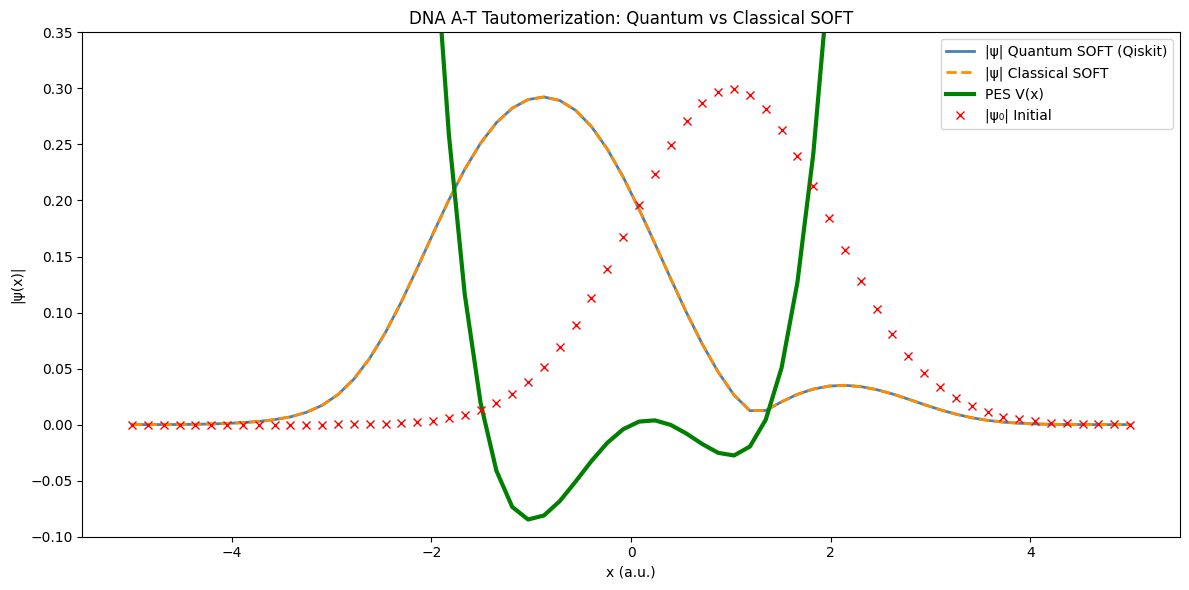

Normalisasi klasik: 1.000000
Normalisasi kuantum: 1.000000


: 

In [ ]:
# ============================================================
# Scripts 4.18–4.19: Classical SOFT Benchmark & Visualisasi
# ============================================================

def soft_step(psi, V_prop_diag, K_prop_diag):
    """
    Satu langkah SOFT klasik.
    
    Pipeline:
    psi → kalikan Vprop → FFT → kalikan Kprop → IFFT → psi_new
    
    Analogi: seperti memasak di microwave (domain waktu) vs oven konvensional
    (domain frekuensi) — SOFT bolak-balik antara dua representasi.
    """
    out = V_prop_diag * psi             # potential step (domain posisi)
    fp  = np.fft.fft(out) * K_prop_diag  # kinetic step (domain momentum)
    return np.fft.ifft(fp)              # kembali ke domain posisi

psi_c = psi.copy()
for _ in range(n_steps):
    psi_c = soft_step(psi_c, np.diag(VVd_prop), np.diag(KEd_prop))

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, np.abs(psin),   lw=2,   label='|ψ| Quantum SOFT (Qiskit)',   color='steelblue')
ax.plot(x, np.abs(psi_c),  lw=2, ls='--', label='|ψ| Classical SOFT', color='darkorange')
ax.plot(x, VV,             lw=3,   label='PES V(x)',                    color='green')
ax.plot(x, np.abs(psi),    'x',    label='|ψ₀| Initial',               color='red')

ax.set_ylim(-0.1, 0.35)
ax.set_xlabel('x (a.u.)')
ax.set_ylabel('|ψ(x)|')
ax.set_title('DNA A-T Tautomerization: Quantum vs Classical SOFT')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Verifikasi normalisasi
print(f"Normalisasi klasik: {np.sum(np.abs(psi_c)**2):.6f}")
print(f"Normalisasi kuantum: {np.sum(np.abs(psin)**2):.6f}")